# 5 - LSTM (réseau récurrent, PyTorch)

Tous les modèles précédents regardent chaque cycle **isolément** : pour eux, le cycle 180
d'une machine n'a aucun lien avec son cycle 179. Or la panne est un **processus** — les
capteurs dérivent lentement pendant des dizaines de cycles avant la casse. Cette tendance,
c'est de l'information gratuite qu'on jette.

Le **LSTM** (Long Short-Term Memory) est un réseau récurrent fait pour ça : il lit la
**séquence des 30 derniers cycles** et garde en mémoire la trajectoire, pas juste la photo.
C'est l'approche de référence de la littérature sur C-MAPSS. Je le code en **PyTorch**, que
je connais déjà (mon projet DQN sur LunarLander) — même logique : un `nn.Module`, une boucle
d'entraînement, un optimiseur Adam.

Point matériel : tout est dimensionné pour tourner sur **CPU** en quelques minutes par modèle
(fenêtres sous-échantillonnées, petit réseau). Pas besoin d'un GPU dernier cri : un argument
de coût pour MECHA si le modèle doit se réentraîner en usine.

In [1]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import outils_mspr as outils

# Reproductibilité (comme random_state=42 côté sklearn)
torch.manual_seed(outils.SEED)
np.random.seed(outils.SEED)
print("PyTorch", torch.__version__, "— device : CPU")

PyTorch 2.12.0+cpu — device : CPU


## Le réseau

Architecture volontairement petite (on a ~40 000 fenêtres par usine, pas des millions) :

```
Entrée (batch, 30 cycles, nb_features)
  → LSTM(64)  + Dropout(0.2)     # lit la séquence, sort un état par cycle
  → LSTM(32)  + Dropout(0.2)     # on ne garde que le DERNIER état = résumé de la trajectoire
  → Linéaire(16) + ReLU
  → Linéaire(1)                  # RUL (régression) ou logit à risque (classification)
```

Le **dropout** éteint 20 % des neurones au hasard pendant l'entraînement : le réseau ne peut
pas se reposer sur un neurone précis → moins de sur-apprentissage.
Le même réseau sert aux deux tâches, seule la **fonction de perte** change :
`MSELoss` pour le RUL, `BCEWithLogitsLoss(pos_weight≈6.3)` pour `at_risk` (le pos_weight
joue le rôle du `class_weight='balanced'` de sklearn).

**Piège rencontré (et corrigé) : la cible doit être normalisée, comme les features.**
Au premier essai, j'entraînais sur le RUL brut (0 à 125) : la perte plafonnait à ~1730,
c'est-à-dire exactement la **variance du RUL** — le réseau n'avait appris que la moyenne
(R² ≈ 0 sur le test). Explication : les activations internes d'un LSTM (tanh) vivent
entre -1 et 1 ; lui demander de produire "83" oblige la dernière couche à des poids
énormes et rend la descente de gradient très lente. La classification, elle, marchait
du premier coup — sa cible est déjà 0/1. Remède standard : entraîner sur **RUL / 125**
(cible dans [0,1]) et re-multiplier par 125 à la prédiction.

In [2]:
class LSTMNet(nn.Module):
    def __init__(self, nb_features):
        super().__init__()
        self.lstm1 = nn.LSTM(nb_features, 64, batch_first=True)
        self.drop1 = nn.Dropout(0.2)
        self.lstm2 = nn.LSTM(64, 32, batch_first=True)
        self.drop2 = nn.Dropout(0.2)
        self.fc1 = nn.Linear(32, 16)
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x, _ = self.lstm1(x)          # (batch, 30, 64)
        x = self.drop1(x)
        x, _ = self.lstm2(x)          # (batch, 30, 32)
        x = self.drop2(x[:, -1])      # dernier pas de temps = résumé de la fenêtre
        return self.fc2(torch.relu(self.fc1(x))).squeeze(-1)

## La boucle d'entraînement (early stopping "maison")

Comme pour le HGB, on surveille la perte sur la **validation par machine** : si elle ne
s'améliore plus pendant 4 époques, on arrête et on **restaure les meilleurs poids** — le
réseau rendu est celui qui généralisait le mieux, pas celui de la dernière époque.

In [3]:
def entrainer(modele, perte_fn, X_app, y_app, X_val, y_val,
              max_epochs=20, patience=5, batch=512, lr=1e-3):
    opt = torch.optim.Adam(modele.parameters(), lr=lr)
    donnees = DataLoader(TensorDataset(torch.from_numpy(X_app), torch.from_numpy(y_app)),
                         batch_size=batch, shuffle=True)
    X_val_t, y_val_t = torch.from_numpy(X_val), torch.from_numpy(y_val)

    historique = {'perte_app': [], 'perte_val': []}
    meilleure_val, sans_progres, meilleurs_poids = float('inf'), 0, None

    for epoch in range(1, max_epochs + 1):
        modele.train()
        cumul = 0.0
        for xb, yb in donnees:
            opt.zero_grad()
            perte = perte_fn(modele(xb), yb)
            perte.backward()
            opt.step()
            cumul += perte.item() * len(xb)
        perte_app = cumul / len(y_app)

        modele.eval()
        with torch.no_grad():   # validation par morceaux (économie mémoire)
            pertes = [perte_fn(modele(X_val_t[i:i+2048]), y_val_t[i:i+2048]).item()
                      * len(X_val_t[i:i+2048]) for i in range(0, len(X_val_t), 2048)]
        perte_val = sum(pertes) / len(y_val)

        historique['perte_app'].append(perte_app)
        historique['perte_val'].append(perte_val)
        print(f"époque {epoch:2d} | perte app : {perte_app:8.2f} | perte val : {perte_val:8.2f}")

        if perte_val < meilleure_val - 1e-4:
            meilleure_val, sans_progres = perte_val, 0
            meilleurs_poids = {k: v.clone() for k, v in modele.state_dict().items()}
        else:
            sans_progres += 1
            if sans_progres >= patience:
                print(f"early stopping (pas de progrès depuis {patience} époques)")
                break

    modele.load_state_dict(meilleurs_poids)  # on restaure le meilleur réseau
    return historique

## Préparation des fenêtres

Chaque cycle devient une fenêtre = ses 30 derniers cycles (padding au début de vie).
Deux fenêtres voisines se recouvrent à 29/30 : pour l'entraînement on n'en garde qu'une sur
deux (`pas=2`) — deux fois moins de calcul CPU pour une information quasi identique. La
validation et le test gardent tout ce qu'il faut pour juger honnêtement.

In [4]:
def preparer_fenetres(num_usine):
    """Prépare les fenêtres App/Val/Test d'une usine (features déjà MinMax-isées)."""
    App, Val, Test, y_rul_vrai, y_risk_vrai, features = outils.preparer_usine(num_usine)

    scaler = MinMaxScaler().fit(App[features])
    for df in (App, Val, Test):
        df[features] = scaler.transform(df[features])

    X_app, y_app_rul = outils.construire_fenetres(App, features, 'RUL', pas=2)
    _, y_app_risk = outils.construire_fenetres(App, features, 'at_risk', pas=2)
    X_val, y_val_rul = outils.construire_fenetres(Val, features, 'RUL', pas=2)
    _, y_val_risk = outils.construire_fenetres(Val, features, 'at_risk', pas=2)
    X_test, uids = outils.fenetres_test(Test, features)

    print(f"Usine {num_usine} : {X_app.shape[0]} fenêtres d'apprentissage, "
          f"{X_val.shape[0]} de validation, {X_test.shape[0]} machines de test "
          f"({X_app.shape[2]} features)")
    return (X_app, y_app_rul, y_app_risk, X_val, y_val_rul, y_val_risk,
            X_test, uids, y_rul_vrai, y_risk_vrai, scaler, features)

In [5]:
def entrainer_usine(num_usine):
    """Entraîne les 2 LSTM (RUL + at_risk) d'une usine et évalue sur le test officiel."""
    (X_app, y_app_rul, y_app_risk, X_val, y_val_rul, y_val_risk,
     X_test, uids, y_rul_vrai, y_risk_vrai, scaler, features) = preparer_fenetres(num_usine)
    nb_features = X_app.shape[2]
    X_test_t = torch.from_numpy(X_test)

    # --- Régression RUL ---
    # Cible normalisée dans [0,1] (RUL/125) — voir le piège documenté plus haut
    print(f"\n--- LSTM régression RUL — Usine {num_usine} ---")
    torch.manual_seed(outils.SEED)
    lstm_rul = LSTMNet(nb_features)
    hist_rul = entrainer(lstm_rul, nn.MSELoss(),
                         X_app, y_app_rul / outils.RUL_MAX,
                         X_val, y_val_rul / outils.RUL_MAX)

    lstm_rul.eval()
    with torch.no_grad():   # on repasse la prédiction à l'échelle des cycles
        y_pred_rul = np.clip(lstm_rul(X_test_t).numpy() * outils.RUL_MAX, 0, outils.RUL_MAX)
    print(f"\n===== Usine {num_usine} — Régression RUL =====")
    met = outils.resultats_regression(y_rul_vrai, y_pred_rul)
    outils.sauver_metriques('lstm', 'regression', num_usine, met)
    outils.sauver_predictions('lstm', 'regression', num_usine, uids, y_rul_vrai, y_pred_rul)

    # --- Classification at_risk ---
    print(f"\n--- LSTM classification at_risk — Usine {num_usine} ---")
    ratio = float((y_app_risk == 0).sum() / (y_app_risk == 1).sum())
    print(f"pos_weight (rééquilibrage) : {ratio:.2f}")
    torch.manual_seed(outils.SEED)
    lstm_risk = LSTMNet(nb_features)
    perte_clf = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(ratio))
    hist_risk = entrainer(lstm_risk, perte_clf, X_app, y_app_risk, X_val, y_val_risk)

    lstm_risk.eval()
    with torch.no_grad():
        y_proba = torch.sigmoid(lstm_risk(X_test_t)).numpy()
    y_pred_risk = (y_proba >= 0.5).astype(int)
    print(f"\n===== Usine {num_usine} — Classification at_risk =====")
    met = outils.resultats_classification(y_risk_vrai, y_pred_risk, y_proba)
    outils.sauver_metriques('lstm', 'classification', num_usine, met)
    outils.sauver_predictions('lstm', 'classification', num_usine, uids,
                              y_risk_vrai, y_pred_risk, y_proba)

    # --- Sauvegarde (poids torch + scaler, rejouables sans réentraîner) ---
    torch.save(lstm_rul.state_dict(),
               outils.DOSSIER_MODELS / f"lstm_regression_usine{num_usine}.pt")
    torch.save(lstm_risk.state_dict(),
               outils.DOSSIER_MODELS / f"lstm_classification_usine{num_usine}.pt")
    joblib.dump({'scaler': scaler, 'features': features},
                outils.DOSSIER_MODELS / f"lstm_scaler_usine{num_usine}.joblib")
    return hist_rul, hist_risk, y_risk_vrai, y_pred_risk

## Usine 1

In [6]:
hist_rul_U1, hist_risk_U1, y_risk_vrai_U1, pred_risk_U1 = entrainer_usine(1)

Usine 1 : 18256 fenêtres d'apprentissage, 4567 de validation, 200 machines de test (17 features)

--- LSTM régression RUL — Usine 1 ---


époque  1 | perte app :     0.39 | perte val :     0.12


époque  2 | perte app :     0.12 | perte val :     0.11


époque  3 | perte app :     0.12 | perte val :     0.09


époque  4 | perte app :     0.06 | perte val :     0.03


...

époque 16 | perte app :     0.15 | perte val :     0.13


époque 17 | perte app :     0.14 | perte val :     0.13


époque 18 | perte app :     0.14 | perte val :     0.16


époque 19 | perte app :     0.15 | perte val :     0.17


époque 20 | perte app :     0.14 | perte val :     0.12

===== Usine 1 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.975
Precision (alertes justifiées) : 0.917
Recall (machines à risque détectées) : 0.978
F1 : 0.946
ROC-AUC : 0.997


## Usine 2

In [7]:
hist_rul_U2, hist_risk_U2, y_risk_vrai_U2, pred_risk_U2 = entrainer_usine(2)

Usine 2 : 46633 fenêtres d'apprentissage, 11250 de validation, 507 machines de test (18 features)

--- LSTM régression RUL — Usine 2 ---


époque  1 | perte app :     0.23 | perte val :     0.11


époque  2 | perte app :     0.08 | perte val :     0.04


époque  3 | perte app :     0.03 | perte val :     0.02


époque  4 | perte app :     0.03 | perte val :     0.03


...

époque 16 | perte app :     0.15 | perte val :     0.14


époque 17 | perte app :     0.14 | perte val :     0.17


époque 18 | perte app :     0.15 | perte val :     0.17


époque 19 | perte app :     0.14 | perte val :     0.13


époque 20 | perte app :     0.14 | perte val :     0.13

===== Usine 2 — Classification at_risk =====
 ---------- Resultat classification ----------
Accuracy : 0.941
Precision (alertes justifiées) : 0.800
Recall (machines à risque détectées) : 0.982
F1 : 0.882
ROC-AUC : 0.995


## Courbes d'apprentissage

À vérifier : la perte de validation descend puis stagne (l'early stopping coupe au bon
moment). Si elle remontait fortement pendant que la perte d'apprentissage continue de
descendre → sur-apprentissage.

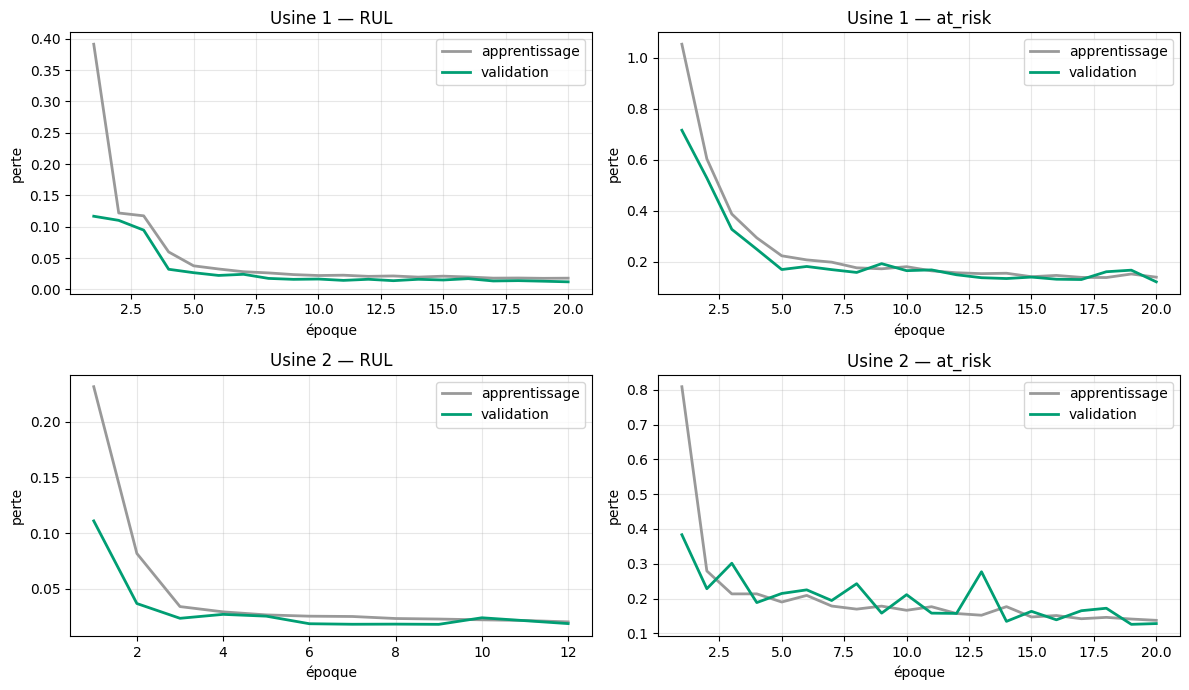

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
courbes = [(hist_rul_U1, 'Usine 1 — RUL'), (hist_risk_U1, 'Usine 1 — at_risk'),
           (hist_rul_U2, 'Usine 2 — RUL'), (hist_risk_U2, 'Usine 2 — at_risk')]
for ax, (hist, titre) in zip(axes.ravel(), courbes):
    epoques = range(1, len(hist['perte_app']) + 1)
    ax.plot(epoques, hist['perte_app'], color='#999999', lw=2, label='apprentissage')
    ax.plot(epoques, hist['perte_val'], color=outils.COULEURS['lstm'], lw=2, label='validation')
    ax.set_title(titre)
    ax.set_xlabel('époque')
    ax.set_ylabel('perte')
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'lstm_courbes_apprentissage.png', dpi=120)
plt.show()

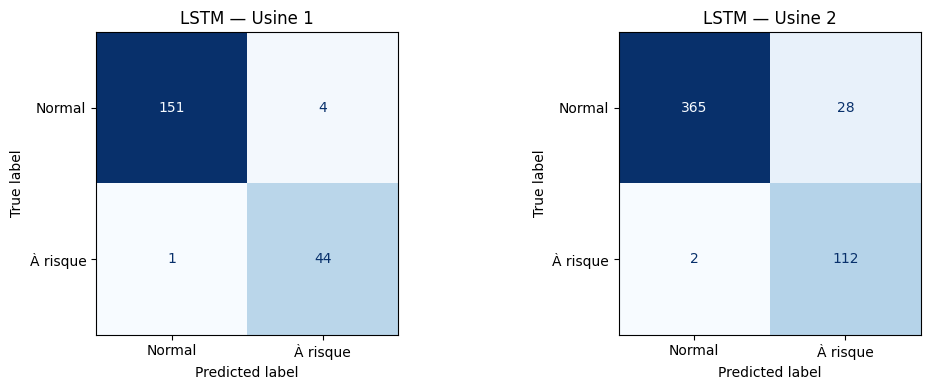

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (num, y_vrai, y_pred) in zip(axes, [(1, y_risk_vrai_U1, pred_risk_U1),
                                            (2, y_risk_vrai_U2, pred_risk_U2)]):
    cm = confusion_matrix(y_vrai, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Normal', 'À risque']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'LSTM — Usine {num}')
plt.tight_layout()
plt.savefig(outils.DOSSIER_FIGURES / 'lstm_confusion.png', dpi=120)
plt.show()

## Lecture et limites

- Le LSTM est le seul modèle du projet qui **voit la tendance** — c'est sur le RUL qu'on
  attend le gain (la vitesse de dérive dit combien de temps il reste).
- **Limites** : moins interprétable (pas d'importance de variables native), plus long à
  entraîner qu'une forêt, et sensible à la longueur de fenêtre (30 cycles ici — un
  hyperparamètre à explorer si on itère).
- Verdict chiffré face à la baseline, à la forêt et au HGB : notebook **06 - Synthèse**.